/tmp/ipython-input-1-3031984912.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return eps * np.pi * np.trapz(L, lam)


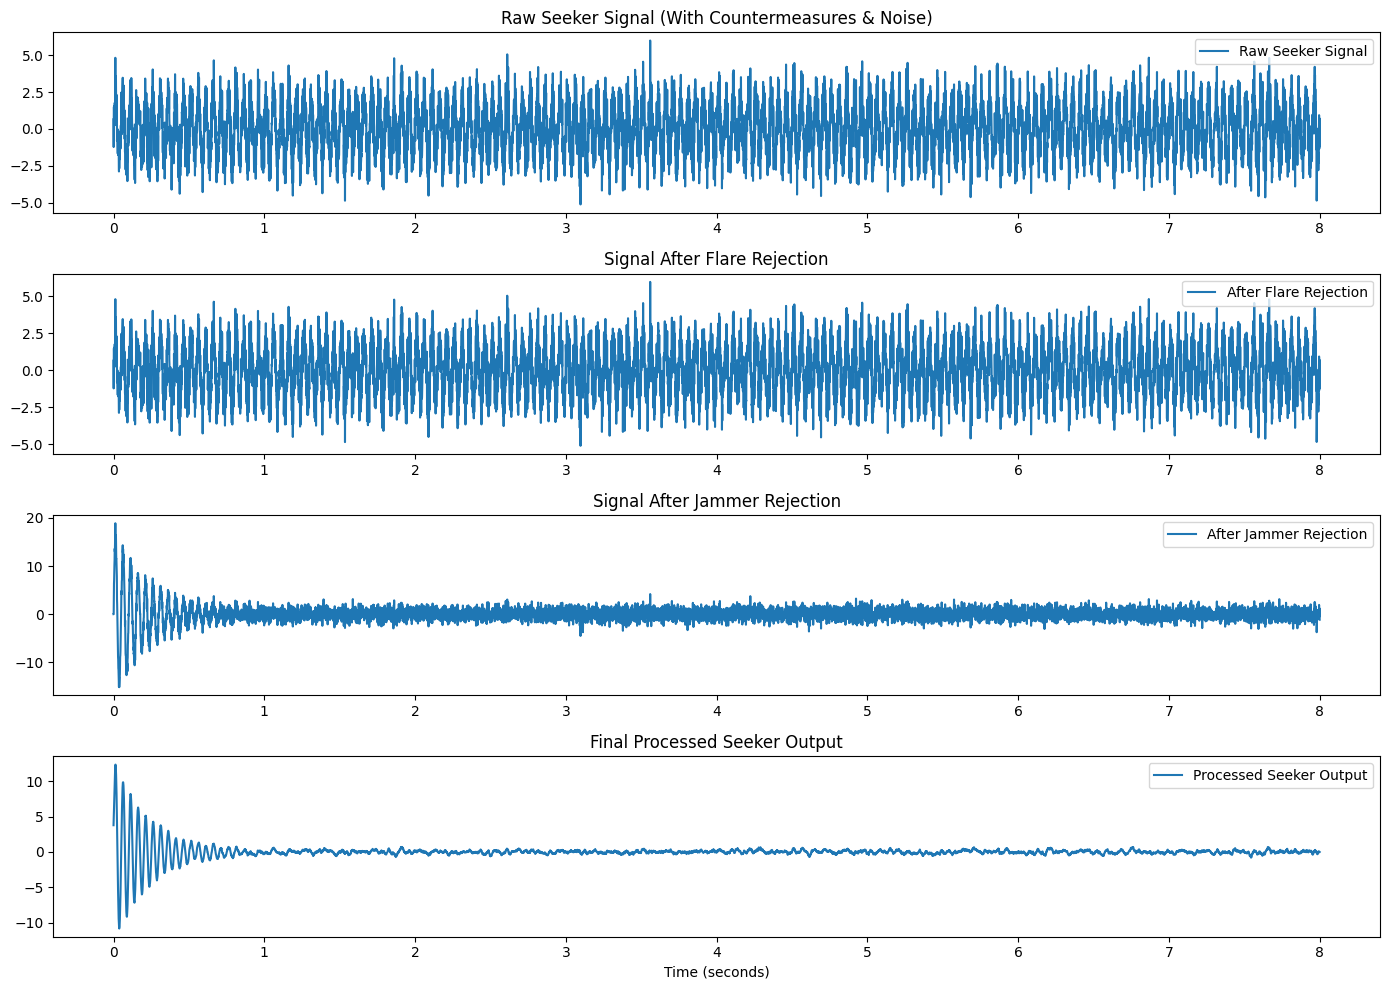

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k

# ==== Physics Models ====

def planck_law(lam, T):
    return 2 * h * c**2 / (lam ** 5) / (np.exp(h * c / (lam * k * T)) - 1)

def total_radiance(T, eps, lam1, lam2, num=1000):
    lam = np.linspace(lam1, lam2, num)
    L = planck_law(lam, T)
    return eps * np.pi * np.trapz(L, lam)

def atmospheric_transmission(kappa, d):
    return np.exp(-kappa * d)

def flare_emission(t, t0, F0, alpha):
    flare = np.zeros_like(t)
    flare[t >= t0] = F0 * np.exp(-alpha * (t[t >= t0] - t0))
    return flare

def ir_jamming(t, J0, omega_jam, phi):
    return J0 * np.sin(omega_jam * t + phi)

def optical_power(N_rec, A_opt, T_opt, Omega_FOV):
    return N_rec * A_opt * T_opt * Omega_FOV

def detector_current(P_in, eta):
    return eta * P_in

def seeker_signal(t, S0, Sm, omega_scan, phi0):
    return S0 + Sm * np.cos(omega_scan * t + phi0)

# ==== Signal Processing ====

def moving_average(x, w):
    return np.convolve(x, np.ones(w) / w, mode='same')

def flare_rejection(signal, threshold=10, decay_rate=6, dt=0.001):
    rejected_signal = np.copy(signal)
    locking = False
    for i in range(1, len(signal)):
        if not locking and signal[i] > threshold and signal[i-1] < threshold:
            locking = True
            t_start = i
        if locking:
            rejected_signal[i] = rejected_signal[t_start] * np.exp(-decay_rate * (i - t_start) * dt)
            if rejected_signal[i] < threshold:  # End of flare spike
                locking = False
    return rejected_signal

def jammer_rejection(signal, t, jammer_freq=20, Q=30):
    fs = 1 / (t[1] - t[0])
    w0 = 2 * np.pi * jammer_freq / fs
    bw = w0 / Q
    b0 = 1
    b1 = -2 * np.cos(w0)
    b2 = 1
    a0 = 1 + bw
    a1 = -2 * np.cos(w0)
    a2 = 1 - bw
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1, a1 / a0, a2 / a0])
    y = np.zeros_like(signal)
    for n in range(2, len(signal)):
        y[n] = b[0] * signal[n] + b[1] * signal[n-1] + b[2] * signal[n-2] - a[1] * y[n-1] - a[2] * y[n-2]
    return y

# ==== Simulation Parameters ====

dt = 0.001
Tsim = 8
n = int(Tsim / dt)
t = np.linspace(0, Tsim, n)

eps_target = 0.8
T_target = 800
lam1 = 3e-6
lam2 = 5e-6
A_opt = 0.01
T_opt = 0.7
Omega_FOV = 1e-5
eta = 0.9
kappa = 0.12
range_to_target = 5000

t0_flare = 3.0
F0_flare = 8000
alpha_flare = 6
J0 = 2
omega_jam = 2 * np.pi * 20
phi_jam = 0

S0 = 5
Sm = 3
omega_scan = 2 * np.pi * 10
phi0 = 0

# ==== Scene and Signal Construction ====

N_target = total_radiance(T_target, eps_target, lam1, lam2)
tau_atm = atmospheric_transmission(kappa, range_to_target)
N_rec = N_target * tau_atm
sig_target = seeker_signal(t, S0, Sm, omega_scan, phi0)
N_flare = flare_emission(t, t0_flare, F0_flare, alpha_flare)
sig_jam = ir_jamming(t, J0, omega_jam, phi_jam)
noise = np.random.normal(scale=1, size=len(t))

P_in = optical_power(N_rec * sig_target + N_flare, A_opt, T_opt, Omega_FOV)
S_det = detector_current(P_in, eta)
S_tot = S_det + sig_jam + noise

# ==== Signal Processing Pipeline ====

S_flare_rej = flare_rejection(S_tot, threshold=10, decay_rate=alpha_flare, dt=dt)
S_jam_rej = jammer_rejection(S_flare_rej, t, jammer_freq=20, Q=30)
S_out = moving_average(S_jam_rej, 20)

# ==== (Optional) Plotting for Diagnostics ====

plt.figure(figsize=(14, 10))
plt.subplot(4,1,1)
plt.plot(t, S_tot, label='Raw Seeker Signal')
plt.title('Raw Seeker Signal (With Countermeasures & Noise)')
plt.legend()

plt.subplot(4,1,2)
plt.plot(t, S_flare_rej, label='After Flare Rejection')
plt.title('Signal After Flare Rejection')
plt.legend()

plt.subplot(4,1,3)
plt.plot(t, S_jam_rej, label='After Jammer Rejection')
plt.title('Signal After Jammer Rejection')
plt.legend()

plt.subplot(4,1,4)
plt.plot(t, S_out, label='Processed Seeker Output')
plt.title('Final Processed Seeker Output')
plt.xlabel('Time (seconds)')
plt.legend()

plt.tight_layout()
plt.show()
